<a href="https://colab.research.google.com/github/kaciLiang/dsci510_finalproject_Kexuan_Liang/blob/main/Liang_Kexuan_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Kexuan Liang

Github Username: kaciLiang

USC ID:3086000006

In [4]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
!unzip -q -o /content/drive/MyDrive/defungi.zip -d /content/data
data_dir = '/content/data/defungi'
print(os.listdir(data_dir))

['.DS_Store', 'C5', 'C4', 'C3', 'C1', 'C2']


# 1-b-i

In [7]:
classes = sorted([c for c in os.listdir(data_dir)
                  if os.path.isdir(os.path.join(data_dir, c))])
print(classes)

train_files, train_labels = [], []
test_files, test_labels = [], []

for label, cls in enumerate(classes):
    files = sorted(glob.glob(os.path.join(data_dir, cls, "*.jpg")))
    n_train = int(0.8 * len(files))

    train_files += files[:n_train]
    train_labels += [label] * n_train

    test_files += files[n_train:]
    test_labels += [label] * (len(files) - n_train)

print("train:", len(train_files), "test:", len(test_files))

['C1', 'C2', 'C3', 'C4', 'C5']
train: 7290 test: 1824


# 1-b-ii

In [8]:
img_size = 224

def load_imgs(files):
    x = np.zeros((len(files), img_size, img_size, 3), dtype=np.uint8)
    for i, f in enumerate(files):
        img = tf.keras.utils.load_img(f, target_size=(img_size, img_size))
        x[i] = tf.keras.utils.img_to_array(img)
    return x

x_train_full = load_imgs(train_files)
x_test = load_imgs(test_files)
y_train_full = tf.keras.utils.to_categorical(train_labels, num_classes=len(classes))
y_test = tf.keras.utils.to_categorical(test_labels, num_classes=len(classes))

print(x_train_full.shape, x_test.shape)

(7290, 224, 224, 3) (1824, 224, 224, 3)


# 1-c-i

In [9]:
def build_model(name, n_classes, img_size):
    inp = layers.Input(shape=(img_size, img_size, 3))

    if name == 'resnet50':
        x = tf.keras.applications.resnet50.preprocess_input(inp)
        base = tf.keras.applications.ResNet50(include_top=False, weights='imagenet',
                                               input_shape=(img_size, img_size, 3), pooling='avg')
    elif name == 'resnet101':
        x = tf.keras.applications.resnet.preprocess_input(inp)
        base = tf.keras.applications.ResNet101(include_top=False, weights='imagenet',
                                                input_shape=(img_size, img_size, 3), pooling='avg')
    elif name == 'efficientnetb0':
        x = tf.keras.applications.efficientnet.preprocess_input(inp)
        base = tf.keras.applications.EfficientNetB0(include_top=False, weights='imagenet',
                                                      input_shape=(img_size, img_size, 3), pooling='avg')
    elif name == 'vgg16':
        x = tf.keras.applications.vgg16.preprocess_input(inp)
        base = tf.keras.applications.VGG16(include_top=False, weights='imagenet',
                                            input_shape=(img_size, img_size, 3), pooling='avg')

    base.trainable = False
    x = base(x, training=False)
    out = layers.Dense(n_classes, activation='softmax')(x)

    model = models.Model(inp, out)
    return model

# 1-c-ii

In [10]:
aug = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.15),])


# 1-c-iii

In [11]:
def build_model(name, n_classes, img_size):
    inp = layers.Input(shape=(img_size, img_size, 3))
    x = aug(inp)

    if name == 'resnet50':
        x = tf.keras.applications.resnet50.preprocess_input(x)
        base = tf.keras.applications.ResNet50(include_top=False, weights='imagenet', input_shape=(img_size, img_size, 3), pooling='avg')
    elif name == 'resnet101':
        x = tf.keras.applications.resnet.preprocess_input(x)
        base = tf.keras.applications.ResNet101(include_top=False, weights='imagenet', input_shape=(img_size, img_size, 3), pooling='avg')
    elif name == 'efficientnetb0':
        x = tf.keras.applications.efficientnet.preprocess_input(x)
        base = tf.keras.applications.EfficientNetB0(include_top=False, weights='imagenet', input_shape=(img_size, img_size, 3), pooling='avg')
    elif name == 'vgg16':
        x = tf.keras.applications.vgg16.preprocess_input(x)
        base = tf.keras.applications.VGG16(include_top=False, weights='imagenet', input_shape=(img_size, img_size, 3), pooling='avg')
    else:
        raise ValueError("unknown model name")

    base.trainable = False
    x = base(x, training=False)
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)

    model = models.Model(inp, out)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# 1-c-iv

In [12]:
backbones = ['resnet50', 'resnet101', 'efficientnetb0', 'vgg16']
histories = {}
models_dict = {}
x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, test_size=0.2, stratify=train_labels, random_state=42)
for name in backbones:
    print('training', name)
    m = build_model(name, len(classes), img_size)
    es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, start_from_epoch=50, restore_best_weights=True)
    ck = tf.keras.callbacks.ModelCheckpoint(f'/content/drive/MyDrive/{name}_best.keras', monitor='val_loss', save_best_only=True)
    h = m.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=100, batch_size=5, callbacks=[es, ck], verbose=1)
    histories[name] = h
    models_dict[name] = m

training resnet50
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/100
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 67s 45ms/step - accuracy: 0.6233 - loss: 1.0102 - val_accuracy: 0.7202 - val_loss: 0.7715
Epoch 2/100
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 48s 41ms/step - accuracy: 0.6878 - loss: 0.8352 - val_accuracy: 0.7675 - val_loss: 0.6872
Epoch 3/100
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 46s 40ms/step - accuracy: 0.7049 - loss: 0.8132 - val_accuracy: 0.7689 - val_loss: 0.6697
Epoch 4/100
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 46s 39ms/step - accuracy: 0.7025 - loss: 0.8275 - val_accuracy: 0.7627 - val_loss: 0.7023
Epoch 5/100
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 48s 41ms/step - accuracy: 0.7159 - loss: 0.7974 - val_accuracy: 0.7764 - val_loss: 0.6969
Epoch 6/100
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 45s 39ms/step - accuracy: 0.7205 - loss: 0.7961 - val_accuracy: 0.7668 - val_loss: 0.6948
Epoch 7/100
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 45s 39ms/step - accuracy: 0.7205 - loss: 0.8159 - val_accuracy: 0.7743 - val_loss: 0.6969


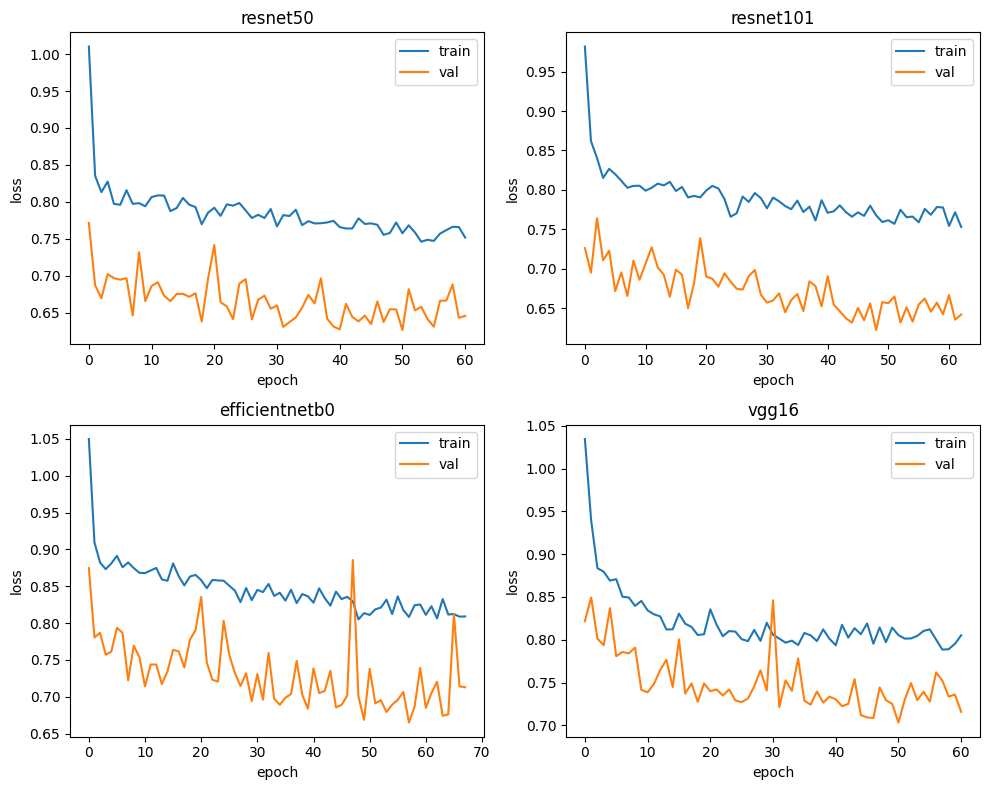

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, name in zip(axes.flat, backbones):
    h = histories[name]
    ax.plot(h.history['loss'], label='train')
    ax.plot(h.history['val_loss'], label='val')
    ax.set_title(name)
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss')
    ax.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/loss_curves.png')
plt.show()

# 1-b-v

In [14]:
def get_metrics(model, x, y_true_onehot):
    y_prob = model.predict(x, batch_size=32, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = np.argmax(y_true_onehot, axis=1)
    prec = precision_score(y_true, y_pred, average='macro')
    rec = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    auc = roc_auc_score(y_true_onehot, y_prob, average='macro', multi_class='ovr')
    return prec, rec, f1, auc

results = []
for name in backbones:
    m = models_dict[name]
    for split_name, x, y in [('train', x_train, y_train), ('val', x_val, y_val), ('test', x_test, y_test)]:
        prec, rec, f1, auc = get_metrics(m, x, y)
        results.append([name, split_name, prec, rec, f1, auc])

res_df = pd.DataFrame(results, columns=['model', 'split', 'precision', 'recall', 'f1', 'auc'])
res_df

,model,split,precision,recall,f1,auc
0,resnet50,train,0.880378,0.851530,0.859219,0.967479
1,resnet50,val,0.835499,0.801675,0.813805,0.955368
2,resnet50,test,0.651862,0.672883,0.661715,0.871323
3,resnet101,train,0.883949,0.849818,0.860682,0.968144
4,resnet101,val,0.852942,0.808843,0.825461,0.951627
5,resnet101,test,0.665817,0.680911,0.672023,0.888499
6,efficientnetb0,train,0.874703,0.793034,0.819262,0.955774
7,efficientnetb0,val,0.857272,0.761371,0.792174,0.947783
8,efficientnetb0,test,0.684174,0.655874,0.661765,0.878832
9,vgg16,train,0.849676,0.742197,0.774492,0.944883


Among the four transfer learning models, ResNet101 showed the best overall performance on the test set. It achieved the highest Recall (0.6809), F1 score (0.6720), and AUC (0.8885), indicating the best overall classification performance. Although EfficientNetB0 obtained the highest Precision (0.6842), its Recall, F1 score, and AUC were lower than those of ResNet101. ResNet50 achieved competitive performance but was slightly inferior to ResNet101, while VGG16 produced the lowest scores across all evaluation metrics. Therefore, ResNet101 can be considered the best-performing model for this dataset.